In [228]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Titanic_Data_Sheet.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [229]:

df.dropna(subset=['Age'], inplace=True)
df.reset_index(drop=True, inplace=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
327,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
328,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q
329,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S
330,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C


In [230]:
bins = [0, 11, 21, 31, 41, 51, 61, 71, 81]
labels = ['10s', '20s', '30s', '40s', '50s','60s', '70s', '80s']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)


df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,40s
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,50s
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,70s
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,30s
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,30s
...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,10s
328,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,40s
329,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,30s
330,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,40s


In [231]:


df_AgeGroup = (
    df.groupby(['AgeGroup', 'Survived'])
      .size()
      .unstack(fill_value=0)
)

df_AgeGroup.columns = ['Died', 'Survived']



df_AgeGroup

/tmp/ipython-input-3771578290.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['AgeGroup', 'Survived'])


,Died,Survived
AgeGroup,,
10s,12,10
20s,25,22
30s,86,45
40s,36,20
50s,30,15
60s,10,11
70s,6,3
80s,0,1


In [232]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_AgeGroup = df_AgeGroup.reset_index()
df_AgeGroup['AgeGroup_Encoded'] = le.fit_transform(df_AgeGroup['AgeGroup'])

df_AgeGroup


,AgeGroup,Died,Survived,AgeGroup_Encoded
0,10s,12,10,0
1,20s,25,22,1
2,30s,86,45,2
3,40s,36,20,3
4,50s,30,15,4
5,60s,10,11,5
6,70s,6,3,6
7,80s,0,1,7


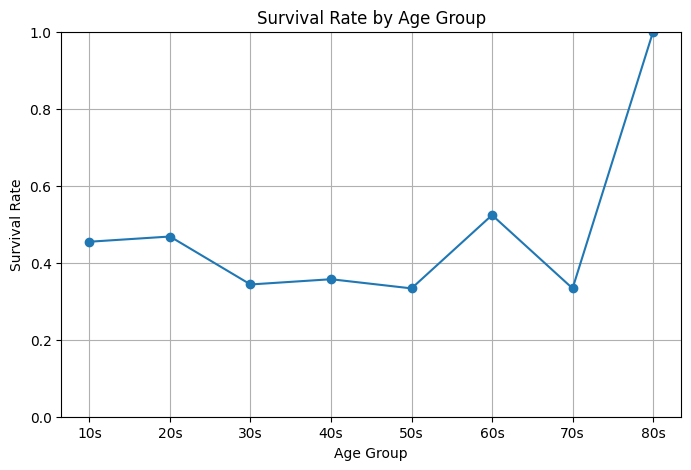

In [233]:
import matplotlib.pyplot as plt


df_AgeGroup['TotalPassengers'] = df_AgeGroup['Died'] + df_AgeGroup['Survived']


df_AgeGroup['SurvivalRate'] = df_AgeGroup['Survived'] / df_AgeGroup['TotalPassengers']


plt.figure(figsize=(8, 5))

plt.plot(
    df_AgeGroup['AgeGroup'],
    df_AgeGroup['SurvivalRate'],
    marker='o'
)

plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Age Group')

plt.ylim(0, 1)
plt.grid(True)

plt.show()




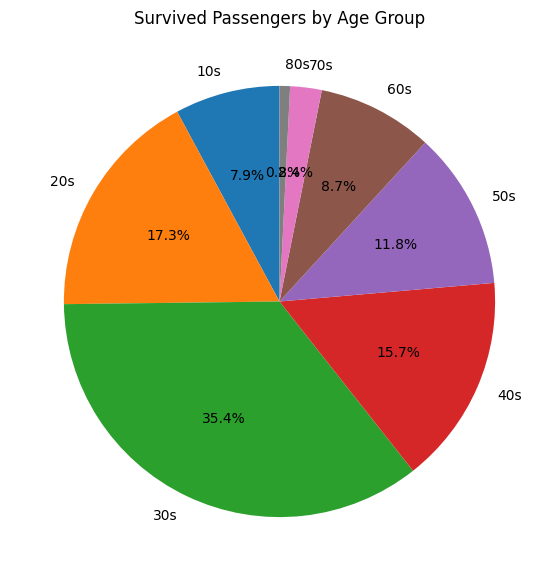

In [234]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.pie(
    df_AgeGroup['Survived'],
    labels=df_AgeGroup['AgeGroup'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Survived Passengers by Age Group')
plt.show()


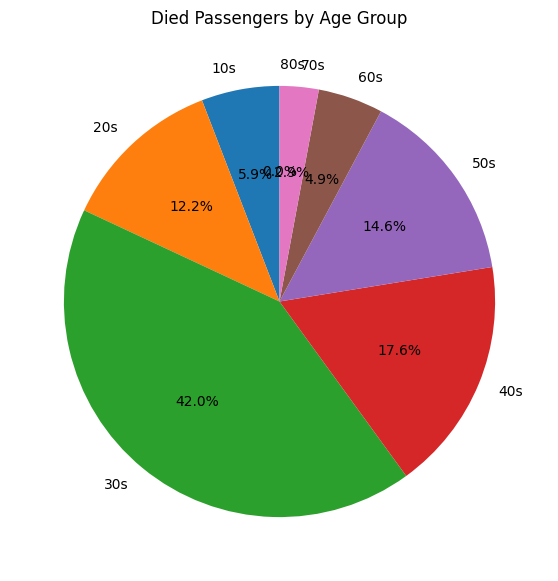

In [235]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.pie(
    df_AgeGroup['Died'],
    labels=df_AgeGroup['AgeGroup'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Died Passengers by Age Group')
plt.show()

In [237]:
df_final = (
    pd.get_dummies(df_AgeGroup, columns=['AgeGroup'])
      .drop(columns=['AgeGroup_Encoded'])
)
df_final

,index,Died,Survived,TotalPassengers,SurvivalRate,AgeGroup_10s,AgeGroup_20s,AgeGroup_30s,AgeGroup_40s,AgeGroup_50s,AgeGroup_60s,AgeGroup_70s,AgeGroup_80s
0,0,12,10,22,0.454545,True,False,False,False,False,False,False,False
1,1,25,22,47,0.468085,False,True,False,False,False,False,False,False
2,2,86,45,131,0.343511,False,False,True,False,False,False,False,False
3,3,36,20,56,0.357143,False,False,False,True,False,False,False,False
4,4,30,15,45,0.333333,False,False,False,False,True,False,False,False
5,5,10,11,21,0.523810,False,False,False,False,False,True,False,False
6,6,6,3,9,0.333333,False,False,False,False,False,False,True,False
7,7,0,1,1,1.000000,False,False,False,False,False,False,False,True


In [238]:


df_final_int = (
    pd.get_dummies(df_AgeGroup, columns=['AgeGroup'], dtype=int)
      .drop(columns=['AgeGroup_Encoded'])
)

df_final_int


,index,Died,Survived,TotalPassengers,SurvivalRate,AgeGroup_10s,AgeGroup_20s,AgeGroup_30s,AgeGroup_40s,AgeGroup_50s,AgeGroup_60s,AgeGroup_70s,AgeGroup_80s
0,0,12,10,22,0.454545,1,0,0,0,0,0,0,0
1,1,25,22,47,0.468085,0,1,0,0,0,0,0,0
2,2,86,45,131,0.343511,0,0,1,0,0,0,0,0
3,3,36,20,56,0.357143,0,0,0,1,0,0,0,0
4,4,30,15,45,0.333333,0,0,0,0,1,0,0,0
5,5,10,11,21,0.523810,0,0,0,0,0,1,0,0
6,6,6,3,9,0.333333,0,0,0,0,0,0,1,0
7,7,0,1,1,1.000000,0,0,0,0,0,0,0,1
